In [1]:
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm

In [2]:
from IPython.core.magic import register_cell_magic

@register_cell_magic
def skip(line, cell):
    pass

In [3]:
k = 10
num_problems = 2000

q_star = np.random.normal(0, 1, (num_problems,k))
arms = [0] * k

for i in range(10):
    arms[i] = np.random.normal(q_star[0, i], 1, 2000) # first problem as a sample

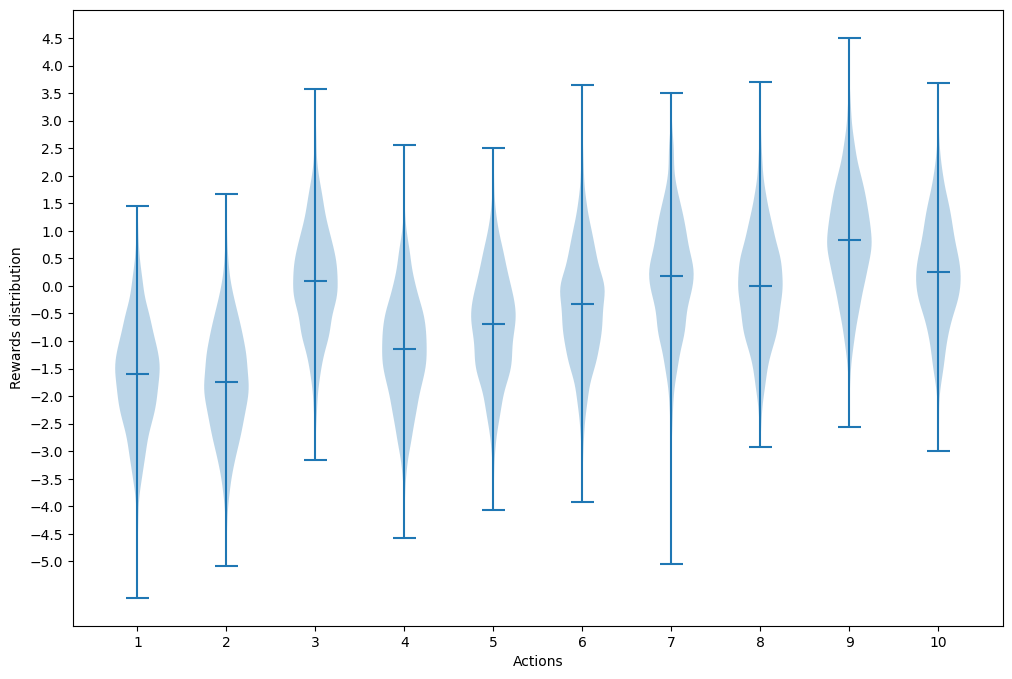

In [4]:
plt.figure(figsize=(12,8))
plt.ylabel('Rewards distribution')
plt.xlabel('Actions')
plt.xticks(range(1,11))
plt.yticks(np.arange(-5,5,0.5))

plt.violinplot(arms, positions=range(1,11), showmedians=True)
plt.show()

**Incremental Implementation**

In [5]:
def bandit(action, problem):
    return np.random.normal(q_star[problem, action], 1)

In [6]:
def simple_max(Q, N, t):
    return np.random.choice(np.flatnonzero(Q == Q.max()))
#this have tie breaking, randomly choose one of the max value, a bit more robust than np.argmax()

In [7]:
def simple_bandit(k, epsilon, steps, init_Q, alpha = 0, argmax_func = simple_max, is_stationary = True):
    rewards = np.zeros(steps)
    actions = np.zeros(steps)

    for i in tqdm(range(num_problems)):
        Q = np.ones(k) * init_Q
        N = np.zeros(k)

        best_action = np.argmax(q_star[i])
        for t in range(steps):
            if np.random.rand() < epsilon: # explore
                a = np.random.randint(k)
            else: # exploit
                a = argmax_func(Q, N, t)

            reward = bandit(a, i)

            N[a] += 1
            if alpha > 0:
                Q[a] = Q[a] + (reward - Q[a]) * alpha
            else:
                Q[a] = Q[a] + (reward - Q[a]) / N[a]

            rewards[t] += reward
            
            if a == best_action:
                actions[t] += 1
            # non-stationary

            if not is_stationary:
                q_star[i] += np.random.normal(0, 0.01, size=k)

    return np.divide(rewards,num_problems), np.divide(actions,num_problems)


In [27]:
ep_0, ac_0 = simple_bandit(k=10, epsilon=0, steps=1000, init_Q=0)
ep_01, ac_01 = simple_bandit(k=10, epsilon=0.01, steps=1000, init_Q=0)
ep_1, ac_1 = simple_bandit(k=10, epsilon=0.1, steps=1000, init_Q=0)

100%|██████████| 2000/2000 [01:17<00:00, 25.70it/s]


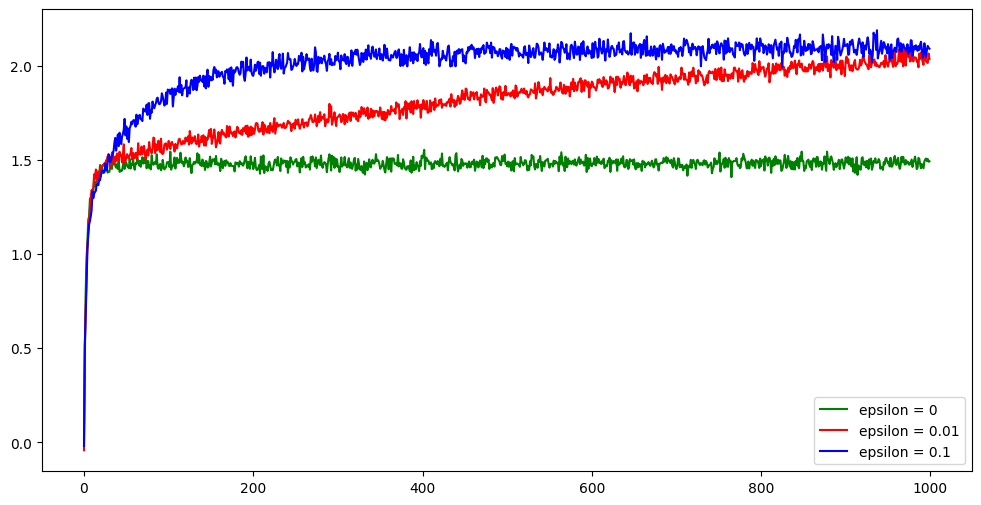

In [28]:
plt.figure(figsize=(12,6))
plt.plot(ep_0, 'g', label='epsilon = 0')
plt.plot(ep_01, 'r', label='epsilon = 0.01')
plt.plot(ep_1, 'b', label='epsilon = 0.1')
plt.legend() 
plt.show()

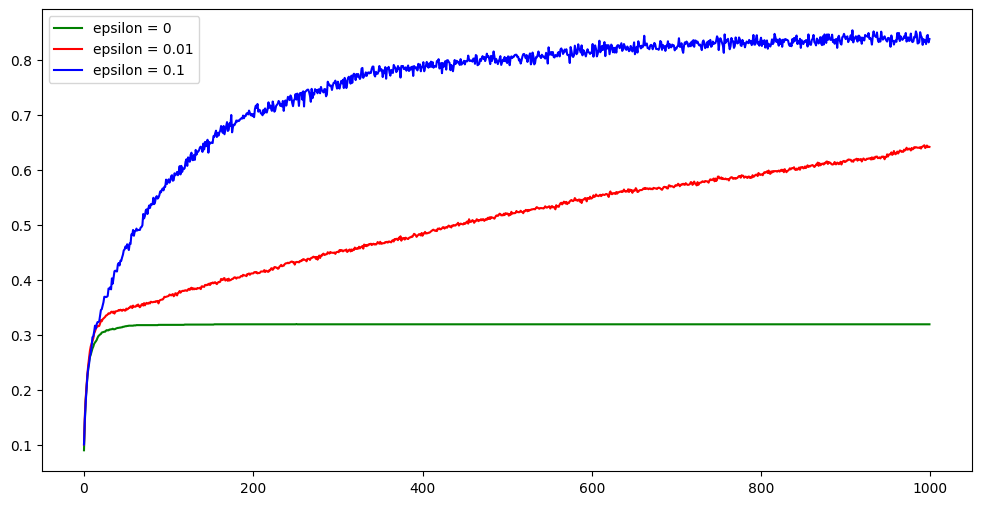

In [29]:
plt.figure(figsize=(12,6))
plt.yticks(np.arange(0,1,0.1))
plt.plot(ac_0, 'g', label='epsilon = 0')
plt.plot(ac_01, 'r', label='epsilon = 0.01')
plt.plot(ac_1, 'b', label='epsilon = 0.1')
plt.legend() 
plt.show()

**Non-stationary problem**

Exercise 2.5

In [23]:
# stationary sample-average (alpha=0)
rewards_avg, actions_avg = simple_bandit(k=10, epsilon=0.1, steps=10000, init_Q=0, alpha=0, is_stationary=False)

# constant step-size (alpha=0.1)
rewards_const, actions_const = simple_bandit(k=10, epsilon=0.1, steps=10000, init_Q=0, alpha=0.1, is_stationary=True)

100%|██████████| 2000/2000 [13:26<00:00,  2.48it/s]


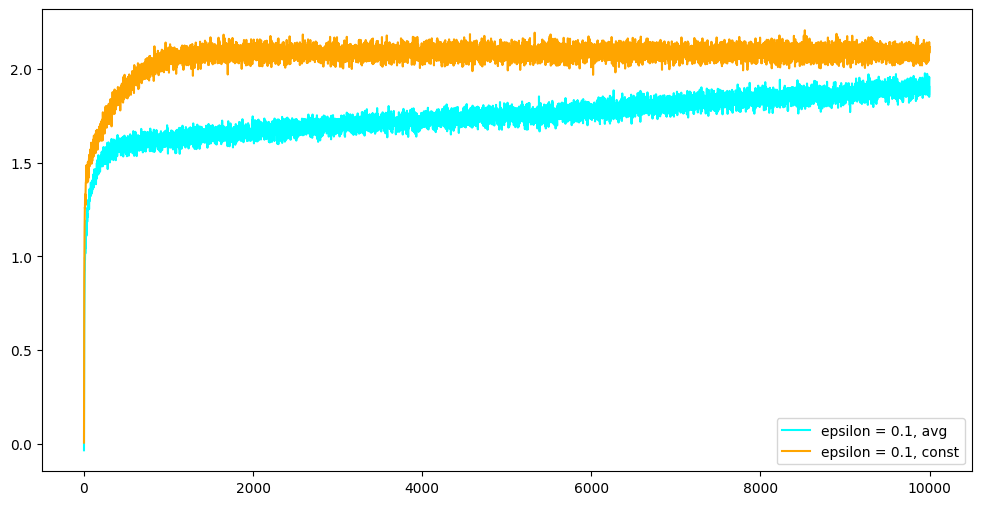

In [26]:
plt.figure(figsize=(12,6))
plt.plot(rewards_avg, 'cyan', label='epsilon = 0.1, avg')
plt.plot(rewards_const, 'orange', label='epsilon = 0.1, const')
plt.legend() 
plt.show()

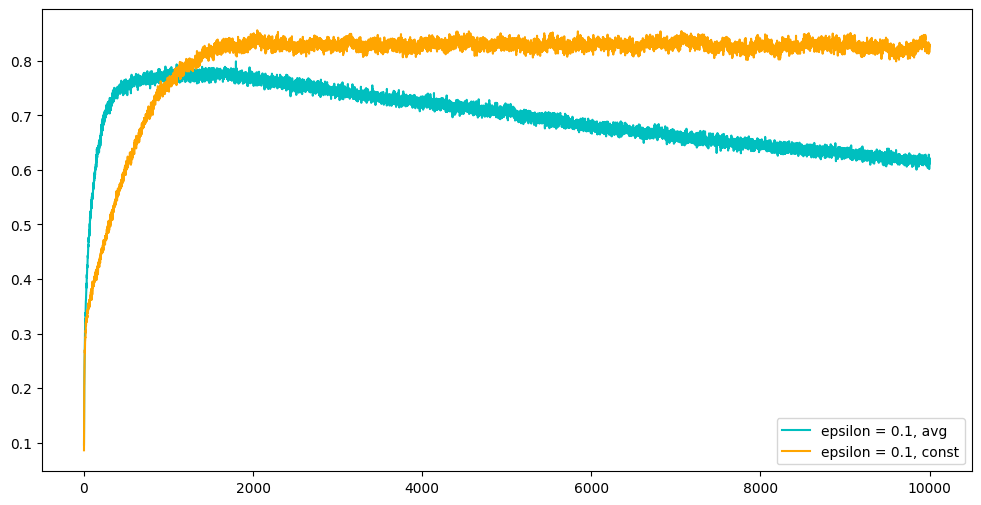

In [25]:
plt.figure(figsize=(12,6))
plt.yticks(np.arange(0,1,0.1))
plt.plot(actions_avg, 'c', label='epsilon = 0.1, avg')
plt.plot(actions_const, 'orange', label='epsilon = 0.1, const')
plt.legend() 
plt.show()

**Optimistic Init Values**

In [ ]:
opt_0, ac_opt_0 = simple_bandit(k=10, epsilon=0, steps=1000, init_Q=5, alpha=0.2)

In [ ]:
plt.figure(figsize=(12,6))
plt.yticks(np.arange(0,3,0.2))
plt.plot(ac_1, 'r', label='Realistic')
plt.plot(ac_opt_0, 'b', label='Optimistic')
plt.legend() 
plt.show()